In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import pickle
from gensim.models import Word2Vec
from scipy.sparse import hstack, csr_matrix
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import silhouette_score

In [73]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\midst\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [74]:
setwd = "D:/Sathish/AIML/Intelligent book recommendations/"
pd.set_option('display.max.columns',None)
pd.set_option('display.max_rows',None)

In [75]:
#Importing dataset
df_1 = pd.read_csv("Audible_Catlog.csv")
df_2 = pd.read_csv("Audible_Catlog_Advanced_Features.csv")

In [76]:
display(df_2.info())
print("\n")
display(df_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          4464 non-null   object 
 1   Author             4464 non-null   object 
 2   Rating             4464 non-null   float64
 3   Number of Reviews  4043 non-null   float64
 4   Price              4464 non-null   int64  
 5   Description        4458 non-null   object 
 6   Listening Time     4464 non-null   object 
 7   Ranks and Genre    4464 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 279.1+ KB


None



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6368 entries, 0 to 6367
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          6368 non-null   object 
 1   Author             6368 non-null   object 
 2   Rating             6368 non-null   float64
 3   Number of Reviews  5737 non-null   float64
 4   Price              6365 non-null   float64
dtypes: float64(3), object(2)
memory usage: 248.9+ KB


None

In [77]:
df_1 = df_1.rename(columns={'Rating':'Comp_Rating','Number of Reviews':'Comp_no.of.reviews','Price':'Comp_Price'})

In [78]:
data = pd.merge(df_2,df_1,on=['Book Name','Author'],how='inner')

In [79]:
display(data.head())
print("\nLast six observations")
display(data.tail())

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Comp_Rating,Comp_no.of.reviews,Comp_Price
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",4.9,313.0,10080.0
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",4.6,3658.0,615.0
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",4.4,20174.0,10378.0
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",4.6,4614.0,888.0
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",4.6,4302.0,1005.0



Last six observations


,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre,Comp_Rating,Comp_no.of.reviews,Comp_Price
4246,Passion and Purity: Learning to Bring Your Lov...,Elisabeth Elliot,4.8,156.0,608,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,4.8,153.0,608.0
4247,Things I Wish I'd Known Before We Got Married,Gary Chapman,4.7,1388.0,516,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,4.7,1379.0,516.0
4248,Things I Wish I'd Known Before We Got Married,Gary Chapman,4.7,1388.0,516,\n\nOops!\nIt's rush hour and traffic is pilin...,-1,-1,4.7,1379.0,516.0
4249,The Disease Delusion: Conquering the Causes of...,Dr. Jeffrey S. Bland,4.7,259.0,12356,Disease care vs health care: Which would you c...,-1,-1,4.7,256.0,12356.0
4250,The Disease Delusion: Conquering the Causes of...,Dr. Jeffrey S. Bland,4.7,259.0,12356,Disease care vs health care: Which would you c...,-1,-1,4.7,256.0,12356.0


In [80]:
data.drop_duplicates(inplace=True)

In [81]:
for i in data.columns:
    print(i)
    print(data[i].value_counts)
    print("\n")

Book Name
<bound method IndexOpsMixin.value_counts of 0       Think Like a Monk: The Secret of How to Harnes...
1       Ikigai: The Japanese Secret to a Long and Happ...
2       The Subtle Art of Not Giving a F*ck: A Counter...
3       Atomic Habits: An Easy and Proven Way to Build...
4       Life's Amazing Secrets: How to Find Balance an...
5                                                 Sapiens
6                                                 Sapiens
7                                Extraordinary Leadership
8                        The Intelligent Investor Rev Ed.
9       Rich Dad Poor Dad: What the Rich Teach Their K...
10      The 5AM Club: Own Your Morning. Elevate Your L...
11                Influence: The Psychology of Persuasion
12      Dream With Your Eyes Open: An Entrepreneurial ...
13                                            The Sandman
14                How to Win Friends and Influence People
15      The Alchemist: A Fable About Following Your Dream
16                

In [82]:
#Deleting the rows which has -1 value in listening and rank variable
data = data[~(data['Listening Time'] == '-1')]

In [83]:
#Let see the Price, Reviews,Rating, Listening time doesn't have a negative val8es
display(data['Rating'][data['Rating']<0].count())
display(data['Number of Reviews'][data['Number of Reviews']< 0].count())
display(data['Price'][data['Price']<0].count())

np.int64(176)

np.int64(0)

np.int64(0)

In [84]:
data['Rating'] = data['Rating'].apply(lambda x: 0 if x<=0 else x)
data['Rating'][data['Rating']<0].count()

np.int64(0)

Rating         232
Comp_Rating    232
dtype: int64

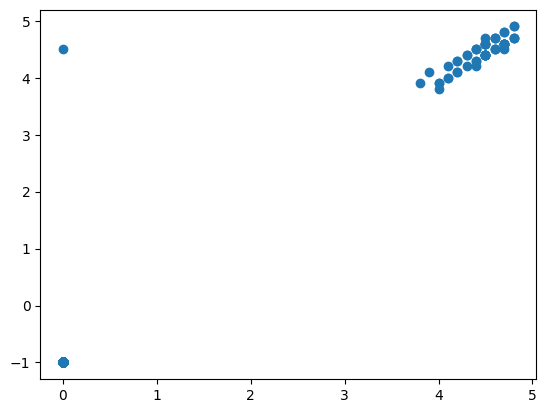

In [85]:
display(data[['Rating','Comp_Rating']][data['Rating']!=data['Comp_Rating']].count())
plt.scatter(data['Rating'][data['Rating']!=data['Comp_Rating']],data['Comp_Rating'][data['Rating']!=data['Comp_Rating']])
plt.show()

In [86]:
data[['Price','Comp_Price']][data['Comp_Price'] != data['Price']].count()

Price         11
Comp_Price    11
dtype: int64

In [87]:
data[['Number of Reviews','Comp_no.of.reviews']][data['Number of Reviews']!=data['Comp_no.of.reviews']].count()

Number of Reviews     1189
Comp_no.of.reviews    1190
dtype: int64

In [88]:
#11 price values are different than comp_price and 232 rating are different from comp_rating so it is decided to use the rating and price from the master dataset and also more values in number of reviews are different from comp_no.of.reviews
#Drop the Comp_Price,Comp_no.of.reviews
data.drop(['Comp_Price','Comp_Rating','Comp_no.of.reviews'],axis=1,inplace=True)

In [89]:
data = data[~(data['Description'].isnull())]

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1903 entries, 0 to 2912
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1903 non-null   object 
 1   Author             1903 non-null   object 
 2   Rating             1903 non-null   float64
 3   Number of Reviews  1727 non-null   float64
 4   Price              1903 non-null   int64  
 5   Description        1903 non-null   object 
 6   Listening Time     1903 non-null   object 
 7   Ranks and Genre    1903 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 133.8+ KB


In [91]:
#Replacing missing values by mean value in the Number of reviews variables
data['Number of Reviews'] = data['Number of Reviews'].apply(lambda x: data['Number of Reviews'].mean() if pd.isnull(x) else x)

In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1903 entries, 0 to 2912
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1903 non-null   object 
 1   Author             1903 non-null   object 
 2   Rating             1903 non-null   float64
 3   Number of Reviews  1903 non-null   float64
 4   Price              1903 non-null   int64  
 5   Description        1903 non-null   object 
 6   Listening Time     1903 non-null   object 
 7   Ranks and Genre    1903 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 133.8+ KB


In [93]:
#Check the outlier
def check_outlier(x,col_name):
    q1 = x.quantile(0.25)
    q2 = x.quantile(0.50)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    uf = q3 + 1.5*iqr
    lf = q1 - 1.5*iqr
    below = (x<=lf).sum()
    above = (x>=uf).sum()
    return col_name, below, above

In [94]:
for i in data.select_dtypes(include='number').columns:
    print(check_outlier(data[i],i))

('Rating', np.int64(243), np.int64(0))
('Number of Reviews', np.int64(0), np.int64(174))
('Price', np.int64(0), np.int64(108))


In [95]:
#Treat the outliers by replacing their mean values
#Rating
q1 = data['Rating'].quantile(0.25)
q3 = data['Rating'].quantile(0.75)
iqr = q3 - q1
lf = q1 - iqr*1.5
mean = data['Rating'].mean()
data.loc[data['Rating']<=lf,'Rating'] = mean
check_outlier(data['Rating'],'Rating')

('Rating', np.int64(0), np.int64(0))

In [96]:
#Number of Reviews
q1 = data['Number of Reviews'].quantile(0.25)
q3 = data['Number of Reviews'].quantile(0.75)
iqr = q3-q1
uf = q3 + iqr*1.5
rrmean = data['Number of Reviews'].mean()
data.loc[data['Number of Reviews']>=uf,'Number of Reviews']=rrmean
check_outlier(data['Number of Reviews'],'No.of Reviews')

('No.of Reviews', np.int64(0), np.int64(0))

In [97]:
#Price
q1 = data['Price'].quantile(0.25)
q3 = data['Price'].quantile(0.75)
iqr = q3-q1
uf = q3 + iqr*1.5
pmean = int(data['Price'].mean())
data.loc[data['Price']>=uf,'Price']=pmean
check_outlier(data['Number of Reviews'],'No.of Reviews')

('No.of Reviews', np.int64(0), np.int64(0))

In [98]:
data.to_csv('data.csv')

In [99]:
import re
pattern = r"#(\d+)\s+in\s+([^(]+)(?:\(([^)]+)\))?"

#Regex pattern explained:
#(\d+) → captures the rank number.
#\s+in\s+ → matches the word “in” with spaces.
#([^(]+) → captures the category name until a parenthesis.
#(?:\(([^)]+)\))? → optionally captures qualifier inside parentheses
results = []

for idx, raw_text in enumerate(data['Ranks and Genre']):
    entries = raw_text.split(',')
    for item in entries:
        item = item.strip()
        match = re.match(pattern,item)
        if match:
            rank = int(match.group(1))
            category = match.group(2).strip()
            qualifier = match.group(3)
            results.append({"row_index":idx,'genre':category,'rank':rank,'platform':qualifier})
df_1 = pd.DataFrame(results)
df_1.iloc[1760][['genre','rank']]

genre    Audible Audiobooks & Originals
rank                                671
Name: 1760, dtype: object

In [100]:
df_1['genre'] = df_1['genre'].replace("Audible Audiobooks & Originals",'Overall_rank')

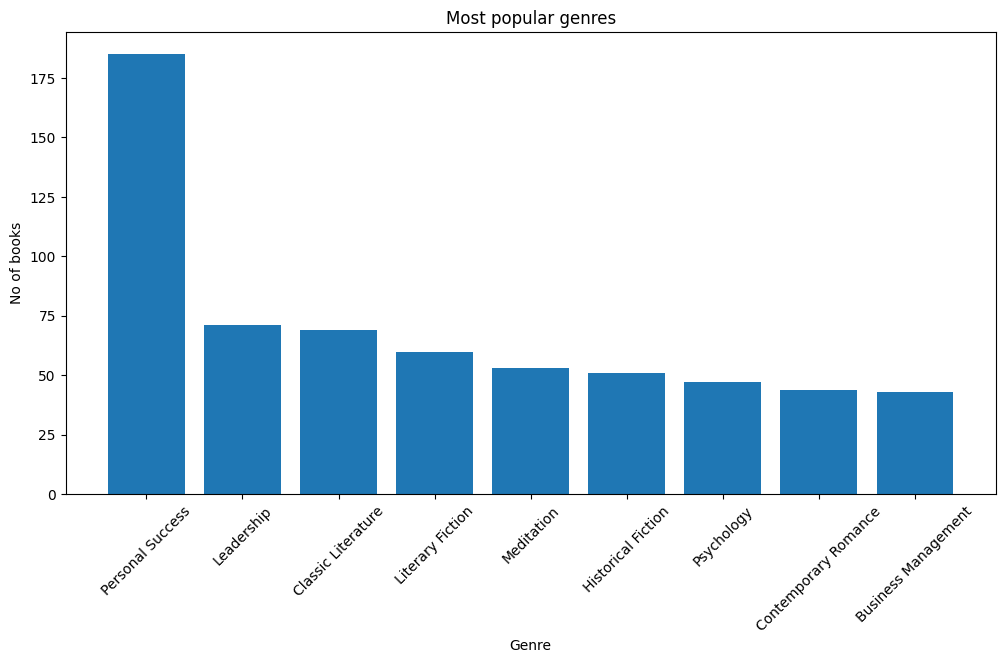

In [101]:
#Exploratory Data Analysis
#Q1. Most popular genres in the dataset
q1 = df_1['genre'].value_counts().reset_index()
q1 = q1[1:10]
fig = plt.subplots(figsize=(12,6))
plt.bar(q1['genre'],q1['count'])
plt.xticks(rotation=45)
plt.xlabel("Genre")
plt.ylabel("No of books")
plt.title("Most popular genres")
plt.show()

In [ ]:
def split_rank_genre(text):
    first_match = re.search(r'#([\d,]+)\s+in', text)
    rank = None
    if first_match:
        rank = first_match.group(1).replace(',', '')  # clean commas
    
    # Extract all categories after "in"
    genres = re.findall(r'in\s+([^,]+)', text)
    
    # Clean and filter out non-genre entries
    genre_clean = []
    for g in genres:
        g = re.sub(r'\(.*?\)', '', g).strip()  # remove parentheses
        if "audible audiobooks" not in g.lower():  # skip platform labels
            genre_clean.append(g)
    
    return pd.Series([rank, ",".join(genre_clean)])

data[['Rank','Genre']] = data['Ranks and Genre'].apply(split_rank_genre)

In [103]:
data['Genre'] = data['Genre'].apply(lambda x: ",".join(sorted([i.strip() for i in x.split(',') if i.strip()])))

In [104]:
#Normalizing 
def normalize_genre(name):
    name = name.lower().strip()
    name = re.sub(r'[^\w\s,]','',name)
    name = re.sub(r'\s+',' ',name)
    return name
data['Genre'] = data['Genre'].apply(normalize_genre)

In [105]:
data.iloc[1760][['Genre']]

Genre    contemporary romance,crime,erotic romance
Name: 2672, dtype: object

In [106]:
data['Author'] = data['Author'].str.lower()
def normalize_author(name):
    name = name.lower().strip()
    name = re.sub(r'[^\w\s]','',name)
    name = re.sub(r'\s+',' ',name)
    return name
data['Author'] = data['Author'].apply(normalize_author)
data['Book Name'] = data['Book Name'].apply(normalize_author)

In [107]:
def clean_text(text):
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r"'", "", text)
    token = word_tokenize(text)
    tokens = [t for t in token if t not in stopwords.words('english') and t not in string.punctuation]
    return " ".join(tokens)
data['Description'] = data['Description'].apply(clean_text)

In [108]:
data.isnull().sum()/data.shape[0]*100

Book Name            0.000000
Author               0.000000
Rating               0.000000
Number of Reviews    0.000000
Price                0.000000
Description          0.000000
Listening Time       0.000000
Ranks and Genre      0.000000
Rank                 1.944298
Genre                0.000000
dtype: float64

In [109]:
data = data[~(data['Rank'].isnull())]
data['Rank'] = data['Rank'].astype(int)
data['Number of Reviews'] = data['Number of Reviews'].astype(int)

In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1866 entries, 0 to 2912
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1866 non-null   object 
 1   Author             1866 non-null   object 
 2   Rating             1866 non-null   float64
 3   Number of Reviews  1866 non-null   int64  
 4   Price              1866 non-null   int64  
 5   Description        1866 non-null   object 
 6   Listening Time     1866 non-null   object 
 7   Ranks and Genre    1866 non-null   object 
 8   Rank               1866 non-null   int64  
 9   Genre              1866 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 160.4+ KB


In [111]:
data.drop('Ranks and Genre',axis=1,inplace=True)

In [112]:
data['hr'] = data['Listening Time'].apply(lambda x: x.split()[0])
data['min'] = data['Listening Time'].apply(lambda x: x.split()[-2] if x.find('minutes')>0 else 0)
data['hr'] = data['hr'].replace('Not','0')
data['hr'] = data['hr'].astype(int)
data['min'] = data['min'].astype(int)
data['time'] = data['hr']+(data['min']/60)

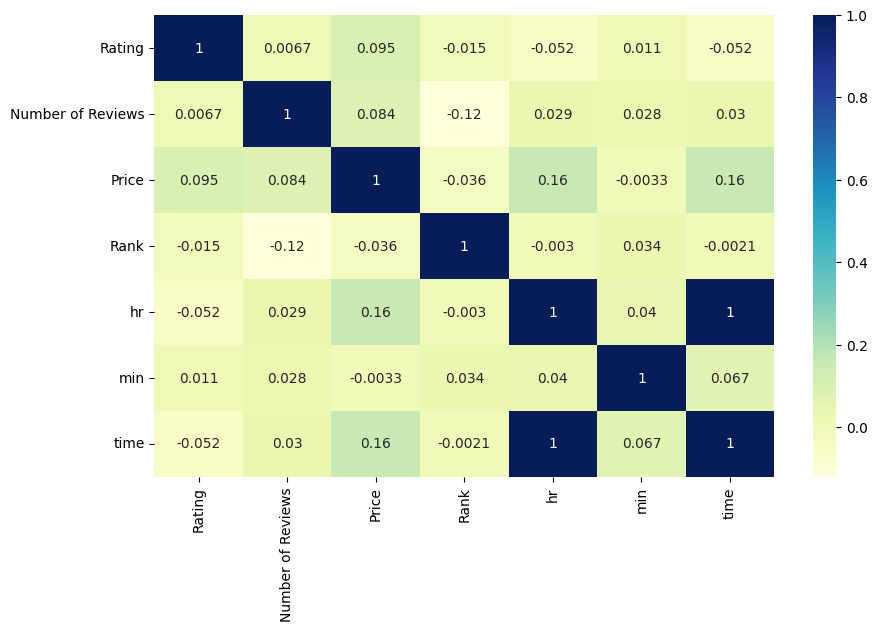

In [113]:
#Checking Multicollinearity
numeric_1 = data.select_dtypes(include='number')
num_corr = numeric_1.corr()
fig=plt.figure(figsize=(10,6))
sns.heatmap(num_corr,annot=True,cmap="YlGnBu")
plt.show()

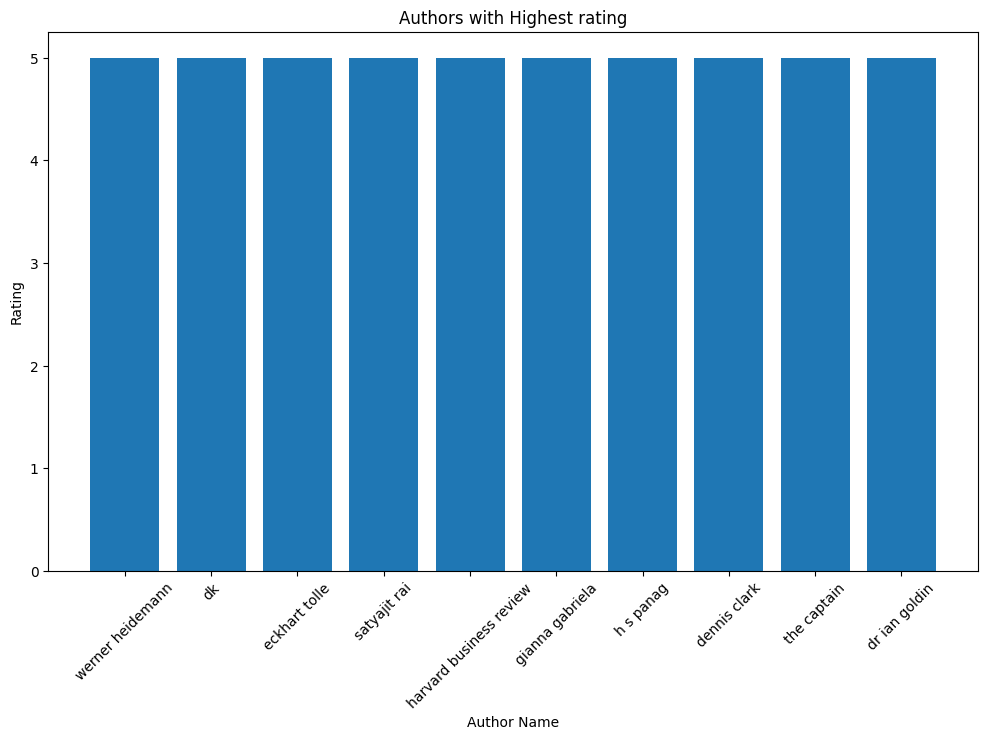

In [114]:
#Q2: Which authors have the highest-rated books?
q2 = data.groupby('Author')['Rating'].max().reset_index()
q2 = q2.sort_values(by='Rating',ascending=False)
q2 = q2[0:10]
fig = plt.figure(figsize=(12,7))
plt.bar(q2['Author'],q2['Rating'])
plt.xticks(rotation=45)
plt.xlabel("Author Name")
plt.ylabel("Rating")
plt.title("Authors with Highest rating")
plt.show()

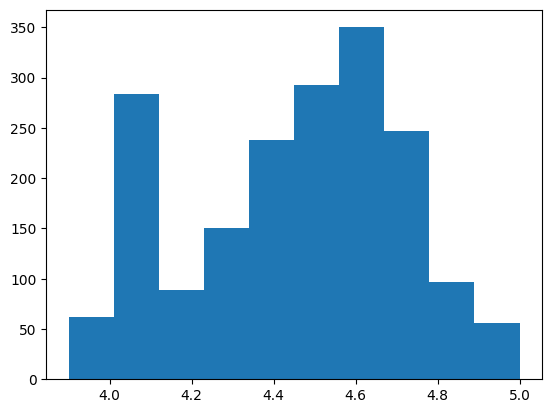

In [115]:
#Q3:Average ratings across books
plt.hist(data['Rating'],bins=10)
plt.show()

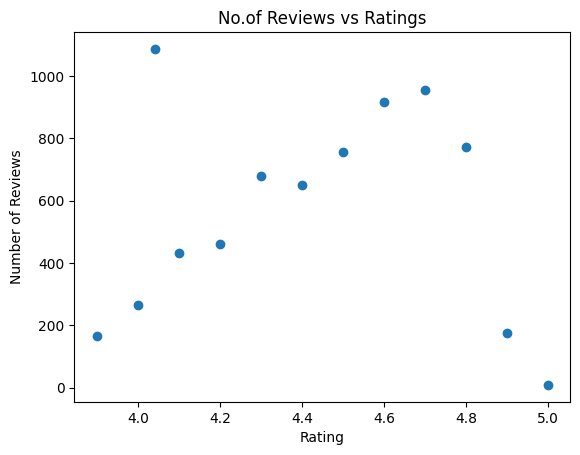

In [116]:
#Q5: Ratings vary between number of reviews
q5 = data.groupby('Rating')['Number of Reviews'].mean().reset_index()
q5 = q5.sort_values(by='Number of Reviews')
plt.scatter(q5['Rating'],q5['Number of Reviews'])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("No.of Reviews vs Ratings")
plt.show()

In [117]:
data.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Rank,Genre,hr,min,time
0,think like a monk the secret of how to harness...,jay shetty,4.9,371,1002,past three years jay shetty become one world ’...,10 hours and 54 minutes,1,"personal success,society culture,stress manage...",10,54,10.900000
1,ikigai the japanese secret to a long and happy...,héctor garcía,4.6,1481,615,brought penguin,3 hours and 23 minutes,2,"meditation,personal success,selfesteem",3,23,3.383333
2,the subtle art of not giving a fck a counterin...,mark manson,4.4,1481,1002,generation-defining self-help guide superstar ...,5 hours and 17 minutes,3,"personal development selfhelp,personal success",5,17,5.283333
3,atomic habits an easy and proven way to build ...,james clear,4.6,1481,888,brought penguin,5 hours and 35 minutes,5,"personal success,psychology,stress management",5,35,5.583333
4,lifes amazing secrets how to find balance and ...,gaur gopal das,4.6,1481,1005,stop going life start growing life,6 hours and 25 minutes,6,"essays,literary essays,spiritualism",6,25,6.416667


In [118]:
#Learn the embeddings from the combined corpus of description and genre
sentences = data['Description'] + data['Genre']
word2vec = Word2Vec(sentences=sentences,vector_size=100,window = 5,min_count=2,workers = 4)

In [119]:
def get_embedding(tokens, model, size=100):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(size)
    return np.mean(vectors, axis=0)
desc_embeddings = np.array([get_embedding(tokens, word2vec) for tokens in data['Description']])
genre_embeddings = np.array([get_embedding(tokens, word2vec) for tokens in data['Genre']])
desc_sparse = csr_matrix(desc_embeddings)
genre_sparse = csr_matrix(genre_embeddings)

In [120]:
tf_author = TfidfVectorizer()
author_vec = tf_author.fit_transform(data['Author'])

In [121]:
x_scaler = StandardScaler()
numeric_scaled = x_scaler.fit_transform(data[['Rating','Number of Reviews']])
numeric_sparse = csr_matrix(numeric_scaled)

In [122]:
#Concantenate all into a one combined vector
combined_1 = hstack([desc_sparse,numeric_scaled,author_vec,genre_sparse])

In [123]:
#Kmean algorithm
kmean = KMeans(n_clusters = 10,random_state=42)
data['Cluster'] = kmean.fit_predict(combined_1)
print(data['Cluster'].value_counts())
labels = data['Cluster']
score = silhouette_score(combined_1.toarray(),labels)
print(score)

Cluster
1    295
5    286
8    236
6    226
4    221
0    194
9    168
7    113
2     87
3     40
Name: count, dtype: int64
0.10381787317914032


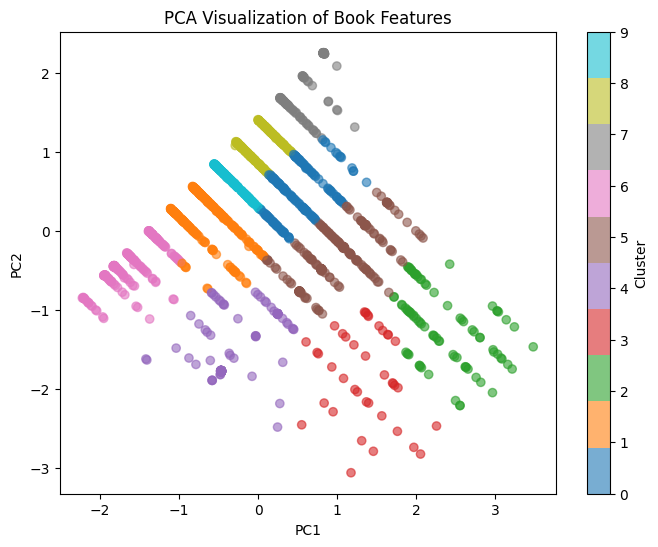

In [124]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(combined_1.toarray())  # if sparse, convert to dense

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=data['Cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title("PCA Visualization of Book Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [125]:
#Building a recommendation system
def recommend_book(book_index,n=5):
    cluster_id = data.loc[book_index,'Cluster']
    cluster_books = data[data['Cluster'] == cluster_id]
    cluster_books = cluster_books[cluster_books.index!=book_index]
    cluster_books = cluster_books.sort_values(by='Rating',ascending = False)
    return cluster_books.head(n)

In [126]:
#Precision function
def precision_at_k(book_index, k=5):
    input_genres = set([g.strip().lower() for g in data.loc[book_index, 'Genre'].split(',')])
    recommended = recommend_book(book_index, n=k)
    relevant = 0
    for _, row in recommended.iterrows():
        rec_genres = set([g.strip().lower() for g in row['Genre'].split(',')])
        if len(input_genres & rec_genres) > 0:
            relevant += 1
    precision = relevant / k if k > 0 else 0
    return precision

In [127]:
#Recall function
def recall_at_k(book_index, k=5):
    input_genres = set([g.strip().lower() for g in data.loc[book_index, 'Genre'].split(',')])
    recommended = recommend_book(book_index, n=k)
    relevant = 0
    for _, row in recommended.iterrows():
        rec_genres = set([g.strip().lower() for g in row['Genre'].split(',')])
        if len(input_genres & rec_genres) > 0:
            relevant += 1
    cluster_id = data.loc[book_index, 'Cluster']
    cluster_books = data[data['Cluster'] == cluster_id]
    total_relevant = cluster_books['Genre'].apply(lambda g: len(input_genres & set(g.lower().split(','))) > 0).sum()
    recall = relevant / total_relevant if total_relevant > 0 else 0
    return recall

In [128]:
#F1 score
def f1_at_k(book_index, k=5):
    p = precision_at_k(book_index, k=k)
    r = recall_at_k(book_index, k=k)
    if (p + r) == 0:
        return 0
    return 2 * (p * r) / (p + r)

In [129]:
sample_indices = np.random.choice(data.index, size=100, replace=False)
precisions = []
recalls = []
f1= []
for idx in sample_indices:
    p = precision_at_k(idx, k=5)
    r = recall_at_k(idx, k=5)
    f = f1_at_k(idx,k=5)
    precisions.append(p)
    recalls.append(r)
    f1.append(f)
print("Average Precision@5:", np.mean(precisions))
print("Average Recall@5:", np.mean(recalls))
print("Average F1 score:",np.mean(f1))

Average Precision@5: 0.054000000000000006
Average Recall@5: 0.0276525907567064
Average F1 score: 0.03051902938326501


In [130]:
data.drop('Cluster',axis=1,inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1866 entries, 0 to 2912
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book Name          1866 non-null   object 
 1   Author             1866 non-null   object 
 2   Rating             1866 non-null   float64
 3   Number of Reviews  1866 non-null   int64  
 4   Price              1866 non-null   int64  
 5   Description        1866 non-null   object 
 6   Listening Time     1866 non-null   object 
 7   Rank               1866 non-null   int64  
 8   Genre              1866 non-null   object 
 9   hr                 1866 non-null   int64  
 10  min                1866 non-null   int64  
 11  time               1866 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 254.1+ KB


In [131]:
data = data.reset_index(drop=True)
model = SentenceTransformer('all-MiniLM-L6-v2')
desc_matrix = model.encode(data['Description'].tolist(),convert_to_tensor = False)
genre_matrix = model.encode(data['Genre'].tolist(),convert_to_tensor=False)
numeric_scaled = x_scaler.fit_transform(data[['Rating','Number of Reviews']])
genre_matrix = csr_matrix(genre_matrix)
desc_matrix = csr_matrix(desc_matrix)
combined_2 = hstack([desc_matrix,numeric_scaled])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [132]:
kmean = KMeans(n_clusters = 10,random_state=42)
data['Cluster'] = kmean.fit_predict(combined_2)
print(data['Cluster'].value_counts())
labels = data['Cluster']
score = silhouette_score(combined_2,labels)
print(score)

Cluster
2    380
0    341
7    231
5    195
3    141
1    132
6    116
8    116
9    115
4     99
Name: count, dtype: int64
0.12638697106426644


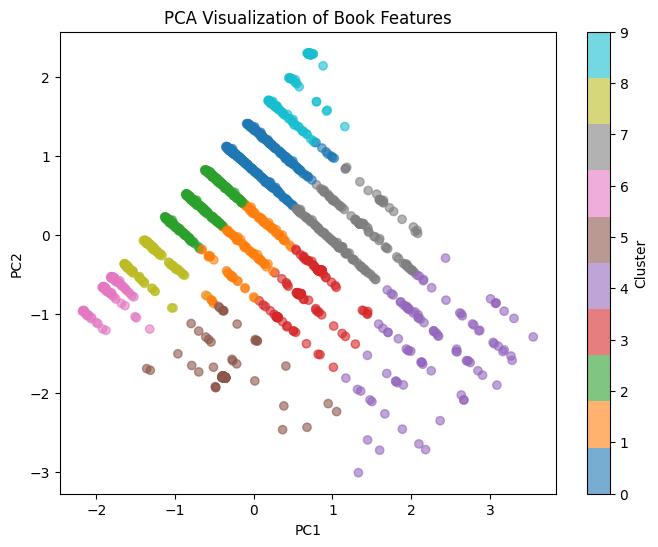

In [133]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(combined_2)  # if sparse, convert to dense

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=data['Cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title("PCA Visualization of Book Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [134]:
sample_indices = np.random.choice(data.index, size=100, replace=False)
precisions = []
recalls = []
for idx in sample_indices:
    p = precision_at_k(idx, k=5)
    r = recall_at_k(idx, k=5)
    precisions.append(p)
    recalls.append(r)
print("Average Precision@5:", np.mean(precisions))
print("Average Recall@5:", np.mean(recalls))

Average Precision@5: 0.054000000000000006
Average Recall@5: 0.02082790409737455


In [135]:
data.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Rank,Genre,hr,min,time,Cluster
0,think like a monk the secret of how to harness...,jay shetty,4.9,371,1002,past three years jay shetty become one world ’...,10 hours and 54 minutes,1,"personal success,society culture,stress manage...",10,54,10.900000,9
1,ikigai the japanese secret to a long and happy...,héctor garcía,4.6,1481,615,brought penguin,3 hours and 23 minutes,2,"meditation,personal success,selfesteem",3,23,3.383333,7
2,the subtle art of not giving a fck a counterin...,mark manson,4.4,1481,1002,generation-defining self-help guide superstar ...,5 hours and 17 minutes,3,"personal development selfhelp,personal success",5,17,5.283333,3
3,atomic habits an easy and proven way to build ...,james clear,4.6,1481,888,brought penguin,5 hours and 35 minutes,5,"personal success,psychology,stress management",5,35,5.583333,7
4,lifes amazing secrets how to find balance and ...,gaur gopal das,4.6,1481,1005,stop going life start growing life,6 hours and 25 minutes,6,"essays,literary essays,spiritualism",6,25,6.416667,7


In [136]:
#Compute the cosine similarity on genre within each cluster
cluster_genre_sim = {}
for id in data['Cluster'].unique():
    cluster_index = data[data['Cluster']==id].index
    cluster_genre_matrix = genre_matrix[cluster_index]
    sim_matrix = cosine_similarity(cluster_genre_matrix)
    cluster_genre_sim[id] = {'indices':cluster_index,'sim_mat':sim_matrix}

In [137]:
#Build a recommendation system based on the cosine similarity
def recommend_cosine(book_index,k=5):
    cluster_id = data.loc[book_index,'Cluster']
    cluster_info = cluster_genre_sim[cluster_id]
    cluster_indices = list(cluster_info['indices']) # get all the cluster_genre_sim info for this cluster
    sim_mat = cluster_info['sim_mat']
    pob = cluster_indices.index(book_index) #finding the position of book in the cluster_indices 
    scores = sim_mat[pob]
    ranked_positions = scores.argsort()[::-1]
    ranked_positions = [i for i in ranked_positions if cluster_indices[i] != book_index]
    top_indices = [cluster_indices[i] for i in ranked_positions[:k]]
    return data.loc[top_indices, ['Genre','Rating','Cluster']]

In [138]:
#Precision function
def precision_at_k(book_index, k=5):
    input_genres = set([g.strip().lower() for g in data.loc[book_index, 'Genre'].split(',')])
    recommended = recommend_cosine(book_index, k=k)
    relevant = 0
    for _, row in recommended.iterrows():
        rec_genres = set([g.strip().lower() for g in row['Genre'].split(',')])
        if len(input_genres & rec_genres) > 0:
            relevant += 1
    precision = relevant / k if k > 0 else 0
    return precision

#Recall function
def recall_at_k(book_index, k=5):
    input_genres = set([g.strip().lower() for g in data.loc[book_index, 'Genre'].split(',')])
    recommended = recommend_cosine(book_index, k=k)
    relevant = 0
    for _, row in recommended.iterrows():
        rec_genres = set([g.strip().lower() for g in row['Genre'].split(',')])
        if len(input_genres & rec_genres) > 0:
            relevant += 1
    cluster_id = data.loc[book_index, 'Cluster']
    cluster_books = data[data['Cluster'] == cluster_id]
    total_relevant = cluster_books['Genre'].apply(lambda g: len(input_genres & set(g.lower().split(','))) > 0).sum()
    recall = relevant / total_relevant if total_relevant > 0 else 0
    return recall

In [139]:
sample_indices = np.random.choice(data.index, size=100, replace=False)
precisions = []
recalls = []
f1 =[]
for idx in sample_indices:
    precisions.append(precision_at_k(idx, k=5))
    recalls.append(recall_at_k(idx, k=5))
    f1.append(f1_at_k(idx,k=5))
print("Average Precision@5:", np.mean(precisions))
print("Average Recall@5:", np.mean(recalls))
print("F1 score:",np.mean(f1))

Average Precision@5: 0.65
Average Recall@5: 0.3675264280266131
F1 score: 0.4121738388683327


In [140]:
import pickle

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)

with open("cluster_genre_sim.pkl", "wb") as f:
    pickle.dump(cluster_genre_sim, f)